In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split

url = 'https://raw.githubusercontent.com/kanetkar/LULML/refs/heads/main/ch16/students.csv'
df = pd.read_csv(url)

X = df[['CGPA', 'IQ']]
y = df['Placed']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3,
			random_state = 3)



In [18]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(random_state = 42)
tree.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [19]:
from sklearn.metrics import accuracy_score
y_pred = tree.predict(X_test)
print("Accuracy =", accuracy_score(y_test, y_pred))


Accuracy = 0.9333333333333333


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


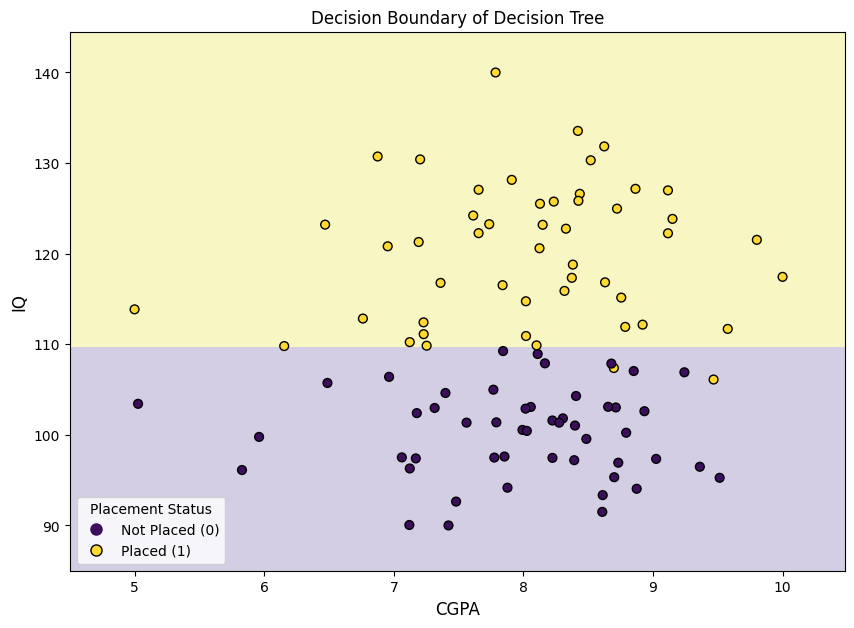

In [21]:
# Create Decision Boundary

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Define plotting range
x_min = X['CGPA'].min() - 0.5
x_max = X['CGPA'].max() + 0.5
y_min = X['IQ'].min() - 5
y_max = X['IQ'].max() + 5

# Create a mesh grid
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.5)
)

# Predict every point in the mesh
Z = tree.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Background colors
bg_colors = ListedColormap(['#c9c2dd', '#f7f5b4'])

# Point colors
point_colors = ListedColormap(['#3b0f5c', '#ffd92f'])

# Plot
plt.figure(figsize=(10,7))

# Decision regions
plt.contourf(xx, yy, Z,
             alpha=0.8,
             cmap=bg_colors)

# Scatter plot
plt.scatter(
    X['CGPA'],
    X['IQ'],
    c=y,
    cmap=point_colors,
    edgecolor='k',
    s=40
)

plt.xlabel("CGPA", fontsize=12)
plt.ylabel("IQ", fontsize=12)
plt.title("Decision Boundary of Decision Tree")

# Legend
import matplotlib.lines as mlines

not_placed = mlines.Line2D([], [], color='#3b0f5c', marker='o',
                           linestyle='None', markersize=8,
                           label='Not Placed (0)')

placed = mlines.Line2D([], [], color='#ffd92f', marker='o',
                       markeredgecolor='k',
                       linestyle='None', markersize=8,
                       label='Placed (1)')

plt.legend(handles=[not_placed, placed],
           title='Placement Status',
           loc='lower left')

plt.show()